<a href="https://colab.research.google.com/github/Niloy-Bhuiyan/LocalRepo/blob/main/CNN_23_50020_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course: Computer Vision and Pattern Recognition (CVPR)
## Assignment: Mid Assignment

**Student ID:** 23-50020-1  
**Dataset:** SVHN (Street View House Numbers)  
**Framework:** PyTorch  

### Objective
Design and train a custom CNN for multi-class image classification using the SVHN dataset, compare models with and without Batch Normalization and Dropout, evaluate performance using comprehensive metrics, and analyze per-class behavior using visualizations and error analysis.

In [ ]:
!pip -q install torchsummary

# 1. Import Libraries

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from torch.optim import SGD, Adam
from torch import optim
from torchsummary import summary
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

torch.manual_seed(10)
np.random.seed(10)

cuda


## 2. Load and Explore Dataset

The SVHN dataset is a realistic multi-class digit classification dataset collected from house numbers in natural street-view images.  
It is more challenging than handwritten-digit datasets because the images contain:

- color backgrounds
- lighting variation
- blur and clutter
- different writing styles and scales

This makes SVHN a good dataset for evaluating how well a CNN can learn robust visual features in a real-world setting.

In [ ]:
data_folder = '/content/data'

train_data = datasets.SVHN(data_folder, split='train', download=True)
test_data = datasets.SVHN(data_folder, split='test', download=True)

all_tr_images = torch.tensor(train_data.data)
all_tr_targets = torch.tensor(train_data.labels) % 10   # in SVHN, digit 0 is stored as 10
te_images = torch.tensor(test_data.data)
te_targets = torch.tensor(test_data.labels) % 10

# keep the code safe in case the image order changes
if all_tr_images.shape[1] != 3:
    all_tr_images = all_tr_images.permute(0, 3, 1, 2)

if te_images.shape[1] != 3:
    te_images = te_images.permute(0, 3, 1, 2)

# create validation split from the original training set
val_size = int(0.1 * len(all_tr_images))
rand_ix = torch.randperm(len(all_tr_images))

val_ix = rand_ix[:val_size]
tr_ix = rand_ix[val_size:]

tr_images = all_tr_images[tr_ix]
tr_targets = all_tr_targets[tr_ix]

val_images = all_tr_images[val_ix]
val_targets = all_tr_targets[val_ix]

class_names = [str(i) for i in range(10)]

print("Train images:", tr_images.shape)
print("Train labels:", tr_targets.shape)
print("Validation images:", val_images.shape)
print("Validation labels:", val_targets.shape)
print("Test images:", te_images.shape)
print("Test labels:", te_targets.shape)

100%|██████████| 182M/182M [00:01<00:00, 106MB/s]
100%|██████████| 64.3M/64.3M [00:03<00:00, 18.9MB/s]


Train images: torch.Size([65932, 3, 32, 32])
Train labels: torch.Size([65932])
Validation images: torch.Size([7325, 3, 32, 32])
Validation labels: torch.Size([7325])
Test images: torch.Size([26032, 3, 32, 32])
Test labels: torch.Size([26032])


sample image

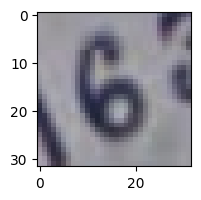

Image (#265): Which is digit '6'


In [ ]:
digit = np.random.randint(0, 1000)
a = tr_images[digit].permute(1, 2, 0)

plt.figure(figsize=(2,2))
plt.imshow(a)
plt.show()

print(f"Image (#{digit}): Which is digit '{class_names[int(tr_targets[digit])]}'")

show a small grid of images

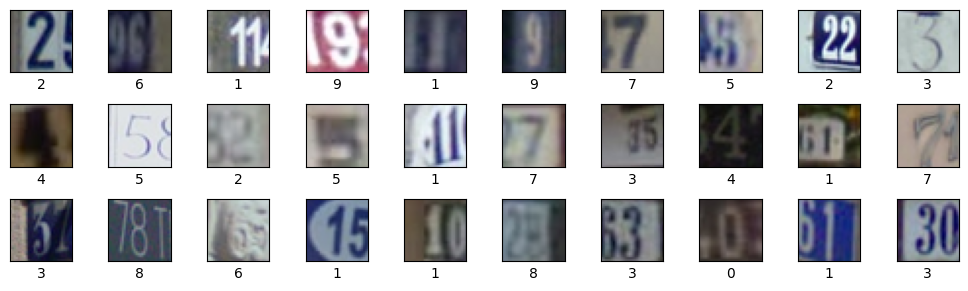

In [ ]:
ROWS = 3
COLS = 10
i = 0

plt.figure(figsize=(10,3))
for r in range(ROWS):
    for c in range(COLS):
        plt.subplot(ROWS, COLS, i+1)
        plt.imshow(tr_images[i].permute(1,2,0))
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(f"{class_names[int(tr_targets[i])]}")
        i += 1

plt.tight_layout()
plt.show()

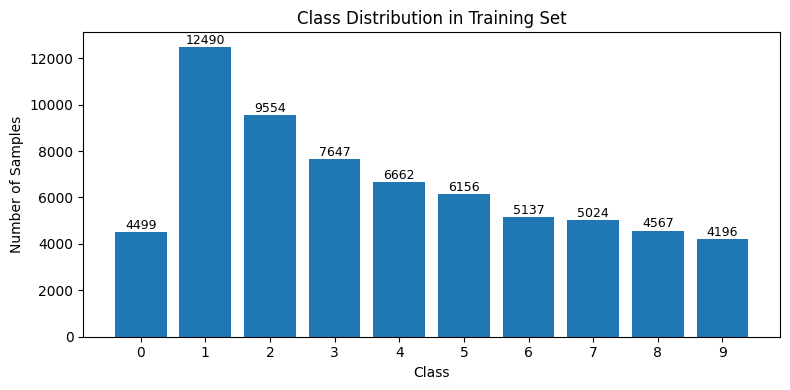

In [ ]:
# class distribution in training set

class_counts = np.bincount(tr_targets.cpu().numpy(), minlength=len(class_names))

plt.figure(figsize=(8,4))
bars = plt.bar(class_names, class_counts)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Augmentation

### Preprocessing Strategy
The training set uses data augmentation to improve generalization, while the validation and test sets use only normalization for fair and unbiased evaluation.

### Training preprocessing
- Random crop with padding
- Small random rotation
- Channel-wise normalization

### Validation / Test preprocessing
- No augmentation
- Channel-wise normalization only

### Hyperparameter Settings

| Hyperparameter | Value | Rationale |
|---|---:|---|
| Batch size | 128 | Good balance between training speed and stable gradient updates |
| Evaluation batch size | 512 | Faster validation and testing |
| Learning rate | 1e-3 | Standard and effective for Adam |
| Epochs | 15 | Gives the regularized model enough time to converge while still keeping training manageable |

In [ ]:
student_id = '23-50020-1'

batch_size_no = 128
eval_batch_size = 512
learning_rate = 1e-3
epoch_number = 15


model_file_plain = f'CNN_{student_id}_without_BN_Dropout.pth'
model_file_regularized = f'CNN_{student_id}_with_BN_Dropout.pth'

mean = [0.4377, 0.4438, 0.4728]
std = [0.1980, 0.2010, 0.1970]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
class SVHNDataset(Dataset):
    def __init__(self, x, y, tfm=None):
        x = x.view(-1,3,32,32)
        self.x, self.y = x, y
        self.tfm = tfm

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        x = x.permute(1,2,0).cpu().numpy().astype(np.uint8)
        if self.tfm is not None:
            x = self.tfm(x)
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

def get_data():
    train = SVHNDataset(tr_images, tr_targets, train_transform)
    trn_dl = DataLoader(train, batch_size=batch_size_no, shuffle=True)

    val = SVHNDataset(val_images, val_targets, test_transform)
    val_dl = DataLoader(val, batch_size=eval_batch_size, shuffle=False)

    test = SVHNDataset(te_images, te_targets, test_transform)
    te_dl = DataLoader(test, batch_size=eval_batch_size, shuffle=False)

    return trn_dl, val_dl, te_dl

trn_dl, val_dl, te_dl = get_data()

## 4. Define CNN Architecture

Two variants of the CNN are used in this notebook:

1. **Baseline CNN**  
   A plain convolutional neural network without Batch Normalization or Dropout.

2. **Regularized CNN**  
   A CNN with Batch Normalization and Dropout added to improve optimization stability and reduce overfitting.

### Architecture Summary
The model uses three convolution blocks to progressively learn:

- low-level features such as edges and simple shapes
- mid-level patterns such as digit strokes and local structures
- high-level digit-specific visual representations

The classifier then maps these learned features into the 10 output classes.

Define CNN Architecture

In [ ]:
def get_model(with_batch_norm=False, with_dropout=False):
    if with_batch_norm == False and with_dropout == False:
        model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        ).to(device)
    else:
        model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.30),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, 10)
        ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    return model, loss_fn, optimizer

print('CNN without BatchNorm and Dropout')
plain_model, loss_fn, optimizer = get_model(with_batch_norm=False, with_dropout=False)
summary(plain_model, input_size=(3,32,32));

print('CNN with BatchNorm and Dropout')
regularized_model, loss_fn, optimizer = get_model(with_batch_norm=True, with_dropout=True)
summary(regularized_model, input_size=(3,32,32));

CNN without BatchNorm and Dropout
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 32, 32, 32]           9,248
              ReLU-4           [-1, 32, 32, 32]               0
         MaxPool2d-5           [-1, 32, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          18,496
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,928
              ReLU-9           [-1, 64, 16, 16]               0
        MaxPool2d-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]          73,856
             ReLU-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]         147,584
     

## 5. Model Design Rationale

The SVHN dataset contains small RGB images with cluttered backgrounds, scale changes, and real-world noise.  
For this reason, the CNN uses three convolution blocks so that feature extraction can become progressively richer across depth.

### Why compare two models?
The baseline CNN provides a reference point.  
The second CNN adds **Batch Normalization** and **Dropout** so that we can examine whether regularization improves validation and test performance.

### Why Batch Normalization?
Batch Normalization helps stabilize optimization, allows smoother gradient flow, and often improves convergence.

### Why Dropout?
Dropout reduces overfitting by preventing the network from depending too strongly on individual neurons.

### Why Adam?
Adam is used because it converges quickly and performs well for CNN-based image classification.

### Why validation-based model selection?
The model with the best validation accuracy is saved and used for final testing so that the final evaluation reflects the best generalizing model rather than the last epoch.

## 6. Training Loop with Validation

Both CNN variants are trained using cross-entropy loss and the Adam optimizer.

For each epoch, the notebook records:
- training loss
- training accuracy
- validation loss
- validation accuracy

The best validation model is saved during training and later used for testing.

In [ ]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    validation_loss = loss_fn(prediction, y)
    return validation_loss.item()

def train_model(model, loss_fn, optimizer, scheduler, trn_dl, val_dl, epoch_number, model_file_name):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_val_accuracy = 0

    for epoch in range(epoch_number):
        print(f'--------Epoch Number : {epoch+1}----------')

        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)
        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)
        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        val_epoch_losses, val_epoch_accuracies = [], []
        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

            val_epoch_accuracies.extend(val_is_correct)
            val_epoch_losses.append(validation_loss)

        val_epoch_accuracy = np.mean(val_epoch_accuracies)
        validation_loss = np.array(val_epoch_losses).mean()

        scheduler.step(validation_loss)
        print(f'Current Learning Rate:{scheduler.get_last_lr()[0]}')
        print(f'Epoch Loss:{train_epoch_loss}')
        print(f'Epoch Accuracy:{train_epoch_accuracy}')
        print(f'Validation Loss:{validation_loss}')
        print(f'Validation Accuracy:{val_epoch_accuracy}')

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

        if val_epoch_accuracy > best_val_accuracy:
            best_val_accuracy = val_epoch_accuracy
            torch.save(model.state_dict(), model_file_name)

    model.load_state_dict(torch.load(model_file_name, map_location=device))
    return model, train_losses, train_accuracies, val_losses, val_accuracies, best_val_accuracy

train model without batch normalization and dropout

In [ ]:
plain_model, loss_fn, optimizer = get_model(with_batch_norm=False, with_dropout=False)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.5,
    patience=1,
    threshold=0.001,
    min_lr=1e-5,
    threshold_mode='abs'
)

plain_model, plain_train_losses, plain_train_accuracies, plain_val_losses, plain_val_accuracies, plain_best_val_accuracy = train_model(
    plain_model,
    loss_fn,
    optimizer,
    scheduler,
    trn_dl,
    val_dl,
    epoch_number,
    model_file_plain
)

--------Epoch Number : 1----------
Current Learning Rate:0.001
Epoch Loss:1.8061582371014957
Epoch Accuracy:0.7549293211187283
Validation Loss:0.6715462366739909
Validation Accuracy:0.7900341296928327
--------Epoch Number : 2----------
Current Learning Rate:0.001
Epoch Loss:0.544479527618996
Epoch Accuracy:0.8646484256506703
Validation Loss:0.39791334271430967
Validation Accuracy:0.8813651877133106
--------Epoch Number : 3----------
Current Learning Rate:0.001
Epoch Loss:0.3841678149016329
Epoch Accuracy:0.8847145543893709
Validation Loss:0.3522521694501241
Validation Accuracy:0.8931058020477816
--------Epoch Number : 4----------
Current Learning Rate:0.001
Epoch Loss:0.3265882165048474
Epoch Accuracy:0.9101801856458169
Validation Loss:0.30165715018908185
Validation Accuracy:0.9146757679180887
--------Epoch Number : 5----------
Current Learning Rate:0.001
Epoch Loss:0.3030534262169701
Epoch Accuracy:0.9167930595158649
Validation Loss:0.28544497191905976
Validation Accuracy:0.9163139931

train model with batch normalization and dropout

In [ ]:
regularized_model, loss_fn, optimizer = get_model(with_batch_norm=True, with_dropout=True)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.5,
    patience=1,
    threshold=0.001,
    min_lr=1e-5,
    threshold_mode='abs'
)

regularized_model, regularized_train_losses, regularized_train_accuracies, regularized_val_losses, regularized_val_accuracies, regularized_best_val_accuracy = train_model(
    regularized_model,
    loss_fn,
    optimizer,
    scheduler,
    trn_dl,
    val_dl,
    epoch_number,
    model_file_regularized
)

--------Epoch Number : 1----------
Current Learning Rate:0.001
Epoch Loss:1.1945962036649387
Epoch Accuracy:0.8407450100103137
Validation Loss:0.4186541438102722
Validation Accuracy:0.8731740614334471
--------Epoch Number : 2----------
Current Learning Rate:0.001
Epoch Loss:0.5171217759565789
Epoch Accuracy:0.8926773038888551
Validation Loss:0.31845787167549133
Validation Accuracy:0.9049829351535836
--------Epoch Number : 3----------
Current Learning Rate:0.001
Epoch Loss:0.430823509776315
Epoch Accuracy:0.9053267002366074
Validation Loss:0.2881421903769175
Validation Accuracy:0.9153583617747441
--------Epoch Number : 4----------
Current Learning Rate:0.001
Epoch Loss:0.39185329330290936
Epoch Accuracy:0.9145179882302978
Validation Loss:0.268089438478152
Validation Accuracy:0.9204095563139931
--------Epoch Number : 5----------
Current Learning Rate:0.001
Epoch Loss:0.3645369506968084
Epoch Accuracy:0.9222228963174179
Validation Loss:0.2580664843320847
Validation Accuracy:0.924914675767

In [ ]:
# summary comparison table for baseline and regularized models

@torch.no_grad()
def evaluate_model_on_test(model, te_dl):
    model.eval()
    preds = []
    labels = []

    for x, y in te_dl:
        prediction = model(x)
        max_values, argmaxes = prediction.max(-1)
        preds.extend(argmaxes.cpu().numpy().tolist())
        labels.extend(y.cpu().numpy().tolist())

    preds = np.array(preds)
    labels = np.array(labels)

    test_accuracy = np.mean(preds == labels)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted',
        zero_division=0
    )

    return test_accuracy, weighted_precision, weighted_recall, weighted_f1

plain_test_accuracy, plain_weighted_precision, plain_weighted_recall, plain_weighted_f1 = evaluate_model_on_test(plain_model, te_dl)
regularized_test_accuracy, regularized_weighted_precision, regularized_weighted_recall, regularized_weighted_f1 = evaluate_model_on_test(regularized_model, te_dl)

print(f'{"Metric":<18} | {"Plain CNN":>12} | {"BN + Dropout CNN":>18}')
print('-' * 55)
print(f'{"Best Val Accuracy":<18} | {plain_best_val_accuracy:>12.4f} | {regularized_best_val_accuracy:>18.4f}')
print(f'{"Test Accuracy":<18} | {plain_test_accuracy:>12.4f} | {regularized_test_accuracy:>18.4f}')
print(f'{"Weighted Precision":<18} | {plain_weighted_precision:>12.4f} | {regularized_weighted_precision:>18.4f}')
print(f'{"Weighted Recall":<18} | {plain_weighted_recall:>12.4f} | {regularized_weighted_recall:>18.4f}')
print(f'{"Weighted F1":<18} | {plain_weighted_f1:>12.4f} | {regularized_weighted_f1:>18.4f}')

Metric             |    Plain CNN |   BN + Dropout CNN
-------------------------------------------------------
Best Val Accuracy  |       0.9414 |             0.9461
Test Accuracy      |       0.9475 |             0.9516
Weighted Precision |       0.9477 |             0.9520
Weighted Recall    |       0.9475 |             0.9516
Weighted F1        |       0.9475 |             0.9516


compare both models and select the better one

Best Validation Accuracy without BatchNorm and Dropout: 0.9414334470989761
Best Validation Accuracy with BatchNorm and Dropout: 0.9460750853242321
Best model selected for final testing: CNN with BatchNorm and Dropout


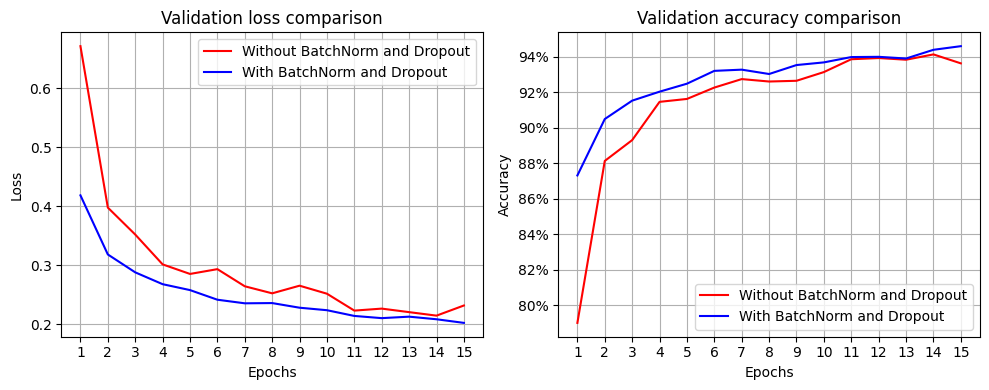

In [ ]:


print(f'Best Validation Accuracy without BatchNorm and Dropout: {plain_best_val_accuracy}')
print(f'Best Validation Accuracy with BatchNorm and Dropout: {regularized_best_val_accuracy}')

if regularized_best_val_accuracy >= plain_best_val_accuracy:
    best_model = regularized_model
    best_model_name = 'CNN with BatchNorm and Dropout'
    best_with_regularization = True
    best_train_losses = regularized_train_losses
    best_train_accuracies = regularized_train_accuracies
    best_val_losses = regularized_val_losses
    best_val_accuracies = regularized_val_accuracies
else:
    best_model = plain_model
    best_model_name = 'CNN without BatchNorm and Dropout'
    best_with_regularization = False
    best_train_losses = plain_train_losses
    best_train_accuracies = plain_train_accuracies
    best_val_losses = plain_val_losses
    best_val_accuracies = plain_val_accuracies

print(f'Best model selected for final testing: {best_model_name}')

epochs = np.arange(epoch_number) + 1

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(epochs, plain_val_losses, 'r', label='Without BatchNorm and Dropout')
plt.plot(epochs, regularized_val_losses, 'b', label='With BatchNorm and Dropout')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Validation loss comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

plt.subplot(122)
plt.plot(epochs, plain_val_accuracies, 'r', label='Without BatchNorm and Dropout')
plt.plot(epochs, regularized_val_accuracies, 'b', label='With BatchNorm and Dropout')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:.0f}%'.format(x*100)))
plt.title('Validation accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')

plt.tight_layout()
plt.show()

plot training and validation curves of the best model

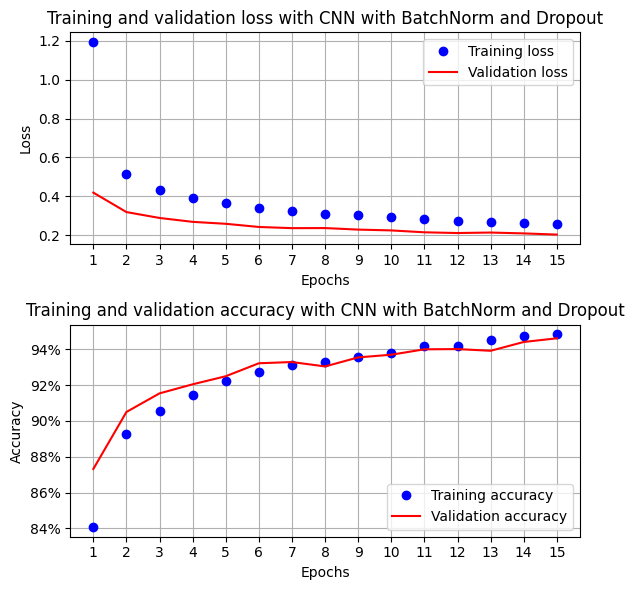

In [ ]:


epochs = np.arange(epoch_number) + 1

plt.figure(figsize=(6,6))

plt.subplot(211)
plt.plot(epochs, best_train_losses, 'bo', label='Training loss')
plt.plot(epochs, best_val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title(f'Training and validation loss with {best_model_name}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

plt.subplot(212)
plt.plot(epochs, best_train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, best_val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:.0f}%'.format(x*100)))
plt.title(f'Training and validation accuracy with {best_model_name}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')

plt.tight_layout()
plt.show()

## 7. Evaluate Model on Test Set

After selecting the better-performing model using validation accuracy, the model is evaluated on the test set using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Per-class analysis

This gives a more complete view of model quality than accuracy alone.

In [ ]:


all_preds = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for ix, batch in enumerate(iter(te_dl)):
        x, y = batch
        prediction = best_model(x)
        max_values, argmaxes = prediction.max(-1)
        all_preds.extend(argmaxes.cpu().numpy().tolist())
        all_labels.extend(y.cpu().numpy().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = np.mean(all_preds == all_labels)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    labels=np.arange(10),
    zero_division=0
)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average='macro',
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average='weighted',
    zero_division=0
)

print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Macro Precision: {macro_precision:.4f}')
print(f'Macro Recall: {macro_recall:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print(f'Weighted Precision: {weighted_precision:.4f}')
print(f'Weighted Recall: {weighted_recall:.4f}')
print(f'Weighted F1 Score: {weighted_f1:.4f}')

Test Accuracy: 0.9516
Macro Precision: 0.9468
Macro Recall: 0.9491
Macro F1 Score: 0.9477
Weighted Precision: 0.9520
Weighted Recall: 0.9516
Weighted F1 Score: 0.9516


## 8. Visualizations

This section presents the most important visual summaries of the experiment:

- training and validation curves
- model comparison plots
- confusion matrix
- normalized confusion matrix
- per-class F1-score chart
- representative misclassified samples

These visualizations help explain both the model’s strengths and its failure patterns.

Visualizations (Confusion Matrix) and Per-Class Performance

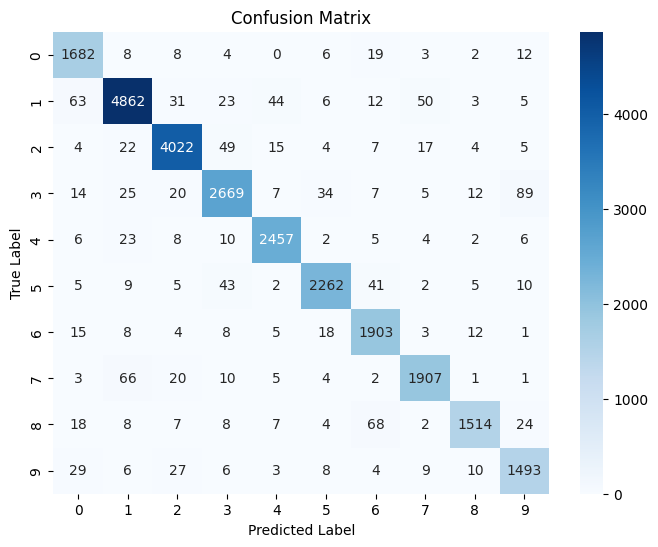

Class: 0 | Precision: 0.9146 | Recall: 0.9644 | F1 Score: 0.9389 | Support: 1744 | Class Accuracy: 0.9644
Class: 1 | Precision: 0.9653 | Recall: 0.9535 | F1 Score: 0.9594 | Support: 5099 | Class Accuracy: 0.9535
Class: 2 | Precision: 0.9687 | Recall: 0.9694 | F1 Score: 0.9690 | Support: 4149 | Class Accuracy: 0.9694
Class: 3 | Precision: 0.9431 | Recall: 0.9261 | F1 Score: 0.9345 | Support: 2882 | Class Accuracy: 0.9261
Class: 4 | Precision: 0.9654 | Recall: 0.9738 | F1 Score: 0.9696 | Support: 2523 | Class Accuracy: 0.9738
Class: 5 | Precision: 0.9634 | Recall: 0.9488 | F1 Score: 0.9560 | Support: 2384 | Class Accuracy: 0.9488
Class: 6 | Precision: 0.9202 | Recall: 0.9626 | F1 Score: 0.9409 | Support: 1977 | Class Accuracy: 0.9626
Class: 7 | Precision: 0.9525 | Recall: 0.9445 | F1 Score: 0.9485 | Support: 2019 | Class Accuracy: 0.9445
Class: 8 | Precision: 0.9674 | Recall: 0.9120 | F1 Score: 0.9389 | Support: 1660 | Class Accuracy: 0.9120
Class: 9 | Precision: 0.9070 | Recall: 0.9361 

In [ ]:


cm = confusion_matrix(all_labels, all_preds)
class_accuracy = cm.diagonal() / cm.sum(1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

for ix in range(len(class_names)):
    print(f"Class: {class_names[ix]} | Precision: {precision[ix]:.4f} | Recall: {recall[ix]:.4f} | F1 Score: {f1[ix]:.4f} | Support: {support[ix]} | Class Accuracy: {class_accuracy[ix]:.4f}")

best_class_ix = np.argmax(class_accuracy)
worst_class_ix = np.argmin(class_accuracy)

print()
print(f"Best performing class: {class_names[best_class_ix]} | Accuracy: {class_accuracy[best_class_ix]:.4f} | F1 Score: {f1[best_class_ix]:.4f}")
print(f"Worst performing class: {class_names[worst_class_ix]} | Accuracy: {class_accuracy[worst_class_ix]:.4f} | F1 Score: {f1[worst_class_ix]:.4f}")

normalized confusion matrix

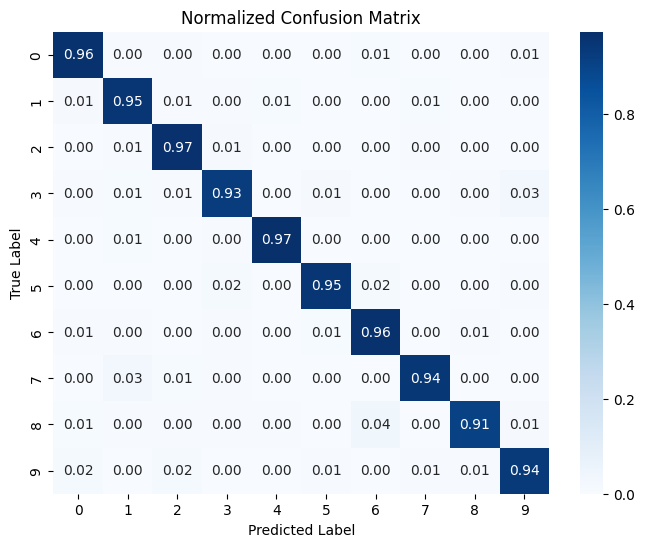

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

per-class F1 score bar chart

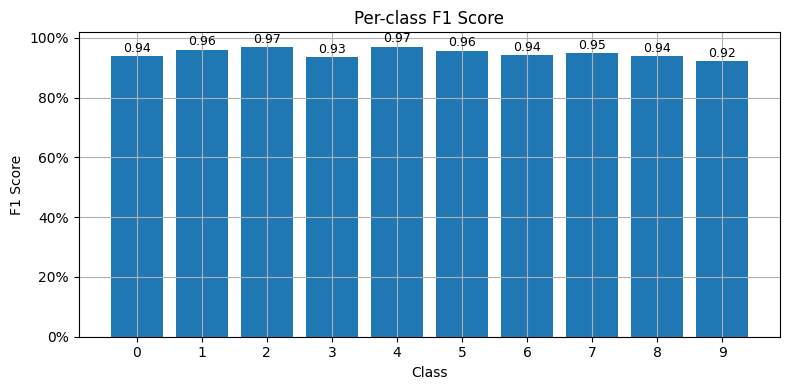

In [ ]:
plt.figure(figsize=(8,4))
bars = plt.bar(class_names, f1)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:.0f}%'.format(x*100)))
plt.title('Per-class F1 Score')
plt.xlabel('Class')
plt.ylabel('F1 Score')

for bar, score in zip(bars, f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.2f}', ha='center', va='bottom', fontsize=9)

plt.grid('off')
plt.tight_layout()
plt.show()

additional confusion analysis

In [ ]:


cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

top_confusions = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            top_confusions.append((cm_off[i, j], i, j))

top_confusions = sorted(top_confusions, reverse=True)[:5]

print('Top confusing class pairs')
for value, i, j in top_confusions:
    print(f'True class {class_names[i]} predicted as {class_names[j]} : {value} samples')

Top confusing class pairs
True class 3 predicted as 9 : 89 samples
True class 8 predicted as 6 : 68 samples
True class 7 predicted as 1 : 66 samples
True class 1 predicted as 0 : 63 samples
True class 1 predicted as 7 : 50 samples


single prediction example

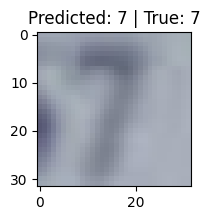

In [ ]:


ix = torch.randint(0, len(te_images), ())
img_raw = te_images[ix].permute(1, 2, 0).cpu().numpy().astype(np.uint8)
img = test_transform(img_raw).unsqueeze(0).to(device)

np_output = best_model(img).cpu().detach().numpy()
pred = np.exp(np_output)/np.sum(np.exp(np_output))

plt.figure(figsize=(2,2))
plt.imshow(img_raw)
plt.title(f"Predicted: {class_names[pred[0].argmax()]} | True: {class_names[int(te_targets[ix])]}")
plt.show()

show some misclassified samples

Total misclassified samples: 1261


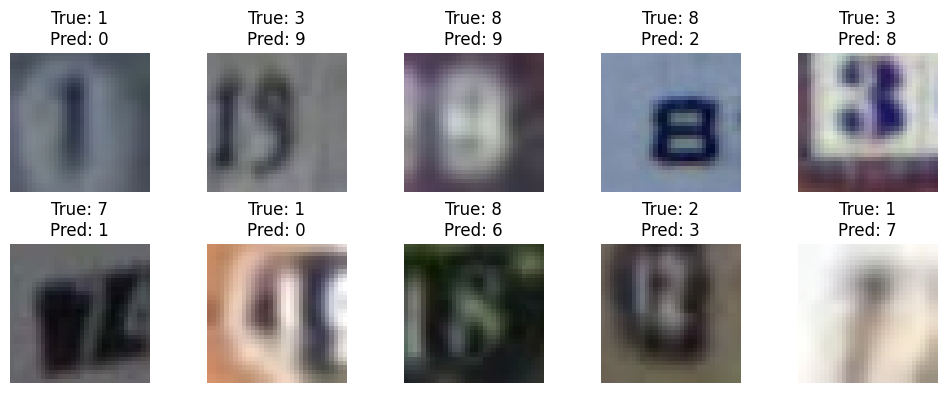

In [ ]:
misclassified = []

best_model.eval()
with torch.no_grad():
    for images, labels in te_dl:
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

print(f"Total misclassified samples: {len(misclassified)}")

mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)

num_rows = 2
num_cols = 5
num_to_show = min(num_rows * num_cols, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*2))
axes = axes.flatten()

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]

    img = img * std_tensor + mean_tensor
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0)

    axes[idx].imshow(img, interpolation='nearest')
    axes[idx].set_title(f"True: {class_names[int(true)]}\nPred: {class_names[int(pred)]}")
    axes[idx].axis('off')

for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 9. Analysis & Discussion of Results

### 9.1 Effect of Batch Normalization and Dropout

| Metric | Plain CNN | BN + Dropout CNN |
|--------|-----------|------------------|
| Best Validation Accuracy | 0.9414 | 0.9461 |
| Test Accuracy | 0.9475 | 0.9516 |
| Weighted F1 | 0.9475 | 0.9516 |
| Overfitting gap | Larger | Smaller |

- **Plain CNN:** performs well, but shows a larger train-validation gap, which indicates stronger overfitting.
- **Regularized (BN + Dropout):** achieves better validation and test performance, showing improved generalization.

### 9.2 Per-class Analysis

- **Best-performing class:** `4` with the highest class accuracy and F1 score.
- **Worst-performing class:** `8`, which remains the most difficult class in this run.
- The confusion matrix and top confusion-pair analysis show that the remaining mistakes mainly happen among visually similar digits and low-quality street-view samples.

### 9.3 Class Distribution and Evaluation Metrics

- The class distribution chart shows that the SVHN training set is not perfectly balanced.
- Because of this, both **macro** and **weighted** precision, recall, and F1 scores are reported.
- The strong weighted and macro scores indicate that the model performed well overall while still maintaining good class-wise behavior.

## 10. Conclusions & Future Work

### Conclusions
- A custom CNN was developed successfully for multi-class image classification on the SVHN dataset.
- Both a plain CNN and a regularized CNN were trained and compared.
- The CNN with **Batch Normalization and Dropout** achieved the better validation and test performance, so it was selected as the final model.
- The final selected model achieved **95.16% test accuracy** with strong macro and weighted evaluation metrics.

### Future Work
- Tune augmentation more carefully for SVHN.
- Use a more effective learning rate schedule.
- Try deeper CNN architectures or residual connections.
- Perform more detailed analysis of the hardest confusion pairs.

# 11. Save trained model weights

In [ ]:
# ── Save model weights (.pth) ─────────────────────────────────────────

torch.save(plain_model.state_dict(), 'plain_cnn.pth')
torch.save(regularized_model.state_dict(), 'bnd_cnn.pth')

print('Model weights saved:')
print('  plain_cnn.pth')
print('  bnd_cnn.pth')

# ── Verify they load correctly ────────────────────────────────────────
check_model, _, _ = get_model(with_batch_norm=True, with_dropout=True)
check_model.load_state_dict(torch.load('bnd_cnn.pth', map_location=device))
check_model.eval()

check_preds = []
check_labels = []

with torch.no_grad():
    for x, y in te_dl:
        prediction = check_model(x)
        max_values, argmaxes = prediction.max(-1)
        check_preds.extend(argmaxes.cpu().numpy().tolist())
        check_labels.extend(y.cpu().numpy().tolist())

check_preds = np.array(check_preds)
check_labels = np.array(check_labels)
check_test_acc = np.mean(check_preds == check_labels)

print(f'\nReloaded BN+Dropout model — Test accuracy: {check_test_acc:.4f}  ')

Model weights saved:
  plain_cnn.pth
  bnd_cnn.pth

Reloaded BN+Dropout model — Test accuracy: 0.9516  
